In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt 
import requests
import seaborn as sns

In [2]:
path =r"C:\Users\PMLS\Downloads\gassolin.csv"
data = pd.read_csv(path)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\PMLS\\Downloads\\gassolin.csv'

In [21]:
data.head()

,REF_DATE,GEO,DGUID,Type of fuel,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,Jan-79,"St. John's, Newfoundland and Labrador",2011S0503001,Regular unleaded gasoline at full service fill...,Cents per litre,57,units,0,v735046,2.1,26.0,NaN,NaN,t,1
1,Jan-79,"Charlottetown and Summerside, Prince Edward Is...",NaN,Regular unleaded gasoline at full service fill...,Cents per litre,57,units,0,v735056,3.1,24.6,NaN,NaN,t,1
2,Jan-79,"Halifax, Nova Scotia",2011S0503205,Regular unleaded gasoline at full service fill...,Cents per litre,57,units,0,v735057,4.1,23.4,NaN,NaN,t,1
3,Jan-79,"Saint John, New Brunswick",2011S0503310,Regular unleaded gasoline at full service fill...,Cents per litre,57,units,0,v735058,5.1,23.2,NaN,NaN,t,1
4,Jan-79,"Québec, Quebec",2011S0503421,Regular unleaded gasoline at full service fill...,Cents per litre,57,units,0,v735059,6.1,22.6,NaN,NaN,t,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41942 entries, 0 to 41941
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   REF_DATE       41942 non-null  object 
 1   GEO            41942 non-null  object 
 2   DGUID          39451 non-null  object 
 3   Type of fuel   41942 non-null  object 
 4   UOM            41942 non-null  object 
 5   UOM_ID         41942 non-null  int64  
 6   SCALAR_FACTOR  41942 non-null  object 
 7   SCALAR_ID      41942 non-null  int64  
 8   VECTOR         41942 non-null  object 
 9   COORDINATE     41942 non-null  float64
 10  VALUE          41942 non-null  float64
 11  STATUS         0 non-null      float64
 12  SYMBOL         0 non-null      float64
 13  TERMINATED     16564 non-null  object 
 14  DECIMALS       41942 non-null  int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 4.8+ MB


In [6]:
data.shape

(41942, 15)

In [7]:
data.columns.tolist()

['REF_DATE',
 'GEO',
 'DGUID',
 'Type of fuel',
 'UOM',
 'UOM_ID',
 'SCALAR_FACTOR',
 'SCALAR_ID',
 'VECTOR',
 'COORDINATE',
 'VALUE',
 'STATUS',
 'SYMBOL',
 'TERMINATED',
 'DECIMALS']

In [8]:
data.isnull().sum()

REF_DATE             0
GEO                  0
DGUID             2491
Type of fuel         0
UOM                  0
UOM_ID               0
SCALAR_FACTOR        0
SCALAR_ID            0
VECTOR               0
COORDINATE           0
VALUE                0
STATUS           41942
SYMBOL           41942
TERMINATED       25378
DECIMALS             0
dtype: int64

In [23]:
dat_copy = (data[['REF_DATE','GEO','Type of fuel','VALUE']]).rename(columns={"REF_DATE" : "DATE", "Type of fuel" : "TYPE"})
dat_copy.head()

,DATE,GEO,TYPE,VALUE
0,Jan-79,"St. John's, Newfoundland and Labrador",Regular unleaded gasoline at full service fill...,26.0
1,Jan-79,"Charlottetown and Summerside, Prince Edward Is...",Regular unleaded gasoline at full service fill...,24.6
2,Jan-79,"Halifax, Nova Scotia",Regular unleaded gasoline at full service fill...,23.4
3,Jan-79,"Saint John, New Brunswick",Regular unleaded gasoline at full service fill...,23.2
4,Jan-79,"Québec, Quebec",Regular unleaded gasoline at full service fill...,22.6


In [25]:
dat_copy[['City', 'Province']] = data['GEO'].str.split(',', n=1, expand=True)

In [27]:
dat_copy.head()

,DATE,GEO,TYPE,VALUE,City,Province
0,Jan-79,"St. John's, Newfoundland and Labrador",Regular unleaded gasoline at full service fill...,26.0,St. John's,Newfoundland and Labrador
1,Jan-79,"Charlottetown and Summerside, Prince Edward Is...",Regular unleaded gasoline at full service fill...,24.6,Charlottetown and Summerside,Prince Edward Island
2,Jan-79,"Halifax, Nova Scotia",Regular unleaded gasoline at full service fill...,23.4,Halifax,Nova Scotia
3,Jan-79,"Saint John, New Brunswick",Regular unleaded gasoline at full service fill...,23.2,Saint John,New Brunswick
4,Jan-79,"Québec, Quebec",Regular unleaded gasoline at full service fill...,22.6,Québec,Quebec


In [29]:
dat_copy['DATE'] = pd.to_datetime(dat_copy['DATE'], format='%b-%y')
dat_copy['Month'] = dat_copy['DATE'].dt.month_name().str.slice(stop=3)

In [31]:
dat_copy.head().T

,0,1,2,3,4
DATE,1979-01-01 00:00:00,1979-01-01 00:00:00,1979-01-01 00:00:00,1979-01-01 00:00:00,1979-01-01 00:00:00
GEO,"St. John's, Newfoundland and Labrador","Charlottetown and Summerside, Prince Edward Is...","Halifax, Nova Scotia","Saint John, New Brunswick","Québec, Quebec"
TYPE,Regular unleaded gasoline at full service fill...,Regular unleaded gasoline at full service fill...,Regular unleaded gasoline at full service fill...,Regular unleaded gasoline at full service fill...,Regular unleaded gasoline at full service fill...
VALUE,26.0,24.6,23.4,23.2,22.6
City,St. John's,Charlottetown and Summerside,Halifax,Saint John,Québec
Province,Newfoundland and Labrador,Prince Edward Island,Nova Scotia,New Brunswick,Quebec
Month,Jan,Jan,Jan,Jan,Jan


In [33]:
dat_copy['Year'] = dat_copy['DATE'].dt.year

In [35]:
dat_copy.head().T

,0,1,2,3,4
DATE,1979-01-01 00:00:00,1979-01-01 00:00:00,1979-01-01 00:00:00,1979-01-01 00:00:00,1979-01-01 00:00:00
GEO,"St. John's, Newfoundland and Labrador","Charlottetown and Summerside, Prince Edward Is...","Halifax, Nova Scotia","Saint John, New Brunswick","Québec, Quebec"
TYPE,Regular unleaded gasoline at full service fill...,Regular unleaded gasoline at full service fill...,Regular unleaded gasoline at full service fill...,Regular unleaded gasoline at full service fill...,Regular unleaded gasoline at full service fill...
VALUE,26.0,24.6,23.4,23.2,22.6
City,St. John's,Charlottetown and Summerside,Halifax,Saint John,Québec
Province,Newfoundland and Labrador,Prince Edward Island,Nova Scotia,New Brunswick,Quebec
Month,Jan,Jan,Jan,Jan,Jan
Year,1979,1979,1979,1979,1979


In [37]:
dat_copy.VALUE.describe()

count    41942.000000
mean        84.784858
std         31.492697
min         18.300000
25%         58.200000
50%         79.200000
75%        110.900000
max        191.600000
Name: VALUE, dtype: float64

<Axes: >

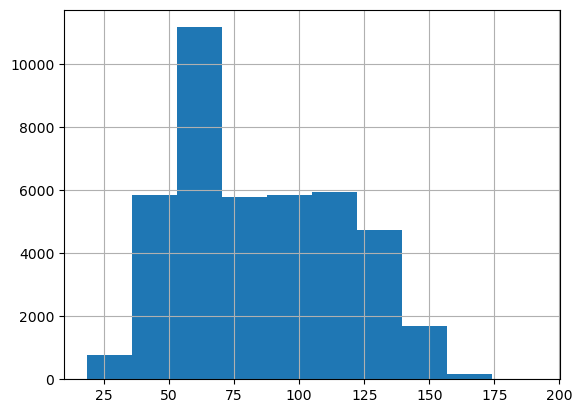

In [39]:
dat_copy.VALUE.hist()

C:\Users\PMLS\AppData\Local\Temp\ipykernel_142148\642549358.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dat_copy["VALUE"],kde=True)


<Axes: xlabel='VALUE', ylabel='Density'>

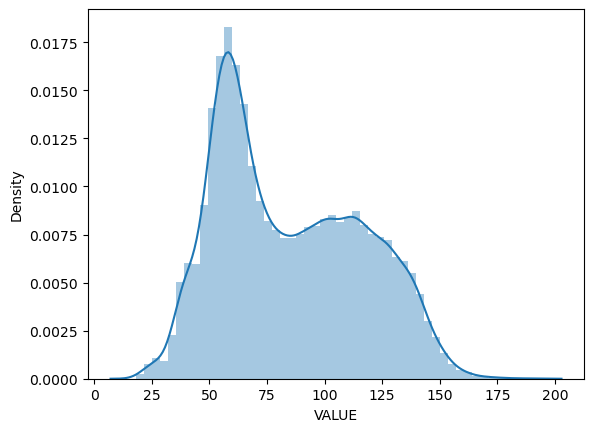

In [41]:
sns.distplot(dat_copy["VALUE"],kde=True)

In [45]:
dat_copy.GEO.unique()

array(["St. John's, Newfoundland and Labrador",
       'Charlottetown and Summerside, Prince Edward Island',
       'Halifax, Nova Scotia', 'Saint John, New Brunswick',
       'Québec, Quebec', 'Montréal, Quebec',
       'Ottawa-Gatineau, Ontario part, Ontario/Quebec',
       'Toronto, Ontario', 'Thunder Bay, Ontario', 'Winnipeg, Manitoba',
       'Regina, Saskatchewan', 'Saskatoon, Saskatchewan',
       'Edmonton, Alberta', 'Calgary, Alberta',
       'Vancouver, British Columbia', 'Victoria, British Columbia',
       'Whitehorse, Yukon', 'Yellowknife, Northwest Territories'],
      dtype=object)

In [47]:
dat_copy.GEO.nunique()

18

In [49]:
dat_copy.GEO.value_counts()

GEO
Winnipeg, Manitoba                                    2491
Regina, Saskatchewan                                  2491
Québec, Quebec                                        2491
Montréal, Quebec                                      2491
Ottawa-Gatineau, Ontario part, Ontario/Quebec         2491
Toronto, Ontario                                      2491
Vancouver, British Columbia                           2491
Charlottetown and Summerside, Prince Edward Island    2491
Victoria, British Columbia                            2467
Whitehorse, Yukon                                     2359
Yellowknife, Northwest Territories                    2339
Saskatoon, Saskatchewan                               2274
St. John's, Newfoundland and Labrador                 2215
Halifax, Nova Scotia                                  2163
Saint John, New Brunswick                             2147
Edmonton, Alberta                                     2109
Calgary, Alberta                                    

In [53]:
dat_copy.TYPE.unique().tolist()

['Regular unleaded gasoline at full service filling stations',
 'Regular unleaded gasoline at self service filling stations',
 'Premium unleaded gasoline at full service filling stations',
 'Premium unleaded gasoline at self service filling stations',
 'Diesel fuel at full service filling stations',
 'Household heating fuel',
 'Diesel fuel at self service filling stations']

In [55]:
dat_copy.TYPE.nunique()

7

In [59]:
dat_copy.TYPE.value_counts()

TYPE
Regular unleaded gasoline at full service filling stations    7086
Regular unleaded gasoline at self service filling stations    6816
Premium unleaded gasoline at self service filling stations    6796
Household heating fuel                                        6112
Diesel fuel at self service filling stations                  5654
Premium unleaded gasoline at full service filling stations    4986
Diesel fuel at full service filling stations                  4492
Name: count, dtype: int64

In [65]:
calgary = dat_copy[dat_copy['GEO'] == 'Calgary, Alberta']
calgary

,DATE,GEO,TYPE,VALUE,City,Province,Month,Year
13,1979-01-01,"Calgary, Alberta",Regular unleaded gasoline at full service fill...,18.7,Calgary,Alberta,Jan,1979
28,1979-02-01,"Calgary, Alberta",Regular unleaded gasoline at full service fill...,18.9,Calgary,Alberta,Feb,1979
43,1979-03-01,"Calgary, Alberta",Regular unleaded gasoline at full service fill...,18.9,Calgary,Alberta,Mar,1979
58,1979-04-01,"Calgary, Alberta",Regular unleaded gasoline at full service fill...,19.1,Calgary,Alberta,Apr,1979
73,1979-05-01,"Calgary, Alberta",Regular unleaded gasoline at full service fill...,19.2,Calgary,Alberta,May,1979
...,...,...,...,...,...,...,...,...
41855,2021-09-01,"Calgary, Alberta",Premium unleaded gasoline at self service fill...,156.6,Calgary,Alberta,Sep,2021
41856,2021-09-01,"Calgary, Alberta",Diesel fuel at self service filling stations,125.1,Calgary,Alberta,Sep,2021
41923,2021-10-01,"Calgary, Alberta",Regular unleaded gasoline at self service fill...,140.8,Calgary,Alberta,Oct,2021
41924,2021-10-01,"Calgary, Alberta",Premium unleaded gasoline at self service fill...,164.4,Calgary,Alberta,Oct,2021


In [75]:
ad_alber = dat_copy[dat_copy["GEO"]=="Edmonton, Alberta"]
ad_alber

,DATE,GEO,TYPE,VALUE,City,Province,Month,Year
12,1979-01-01,"Edmonton, Alberta",Regular unleaded gasoline at full service fill...,18.3,Edmonton,Alberta,Jan,1979
27,1979-02-01,"Edmonton, Alberta",Regular unleaded gasoline at full service fill...,18.5,Edmonton,Alberta,Feb,1979
42,1979-03-01,"Edmonton, Alberta",Regular unleaded gasoline at full service fill...,18.4,Edmonton,Alberta,Mar,1979
57,1979-04-01,"Edmonton, Alberta",Regular unleaded gasoline at full service fill...,18.4,Edmonton,Alberta,Apr,1979
72,1979-05-01,"Edmonton, Alberta",Regular unleaded gasoline at full service fill...,18.6,Edmonton,Alberta,May,1979
...,...,...,...,...,...,...,...,...
41852,2021-09-01,"Edmonton, Alberta",Premium unleaded gasoline at self service fill...,150.7,Edmonton,Alberta,Sep,2021
41853,2021-09-01,"Edmonton, Alberta",Diesel fuel at self service filling stations,123.9,Edmonton,Alberta,Sep,2021
41920,2021-10-01,"Edmonton, Alberta",Regular unleaded gasoline at self service fill...,138.3,Edmonton,Alberta,Oct,2021
41921,2021-10-01,"Edmonton, Alberta",Premium unleaded gasoline at self service fill...,159.6,Edmonton,Alberta,Oct,2021


In [79]:
tornto_orinto = dat_copy[dat_copy["GEO"]== 'Toronto, Ontario']
tornto_orinto

,DATE,GEO,TYPE,VALUE,City,Province,Month,Year
7,1979-01-01,"Toronto, Ontario",Regular unleaded gasoline at full service fill...,23.0,Toronto,Ontario,Jan,1979
22,1979-02-01,"Toronto, Ontario",Regular unleaded gasoline at full service fill...,23.2,Toronto,Ontario,Feb,1979
37,1979-03-01,"Toronto, Ontario",Regular unleaded gasoline at full service fill...,23.2,Toronto,Ontario,Mar,1979
52,1979-04-01,"Toronto, Ontario",Regular unleaded gasoline at full service fill...,23.4,Toronto,Ontario,Apr,1979
67,1979-05-01,"Toronto, Ontario",Regular unleaded gasoline at full service fill...,23.4,Toronto,Ontario,May,1979
...,...,...,...,...,...,...,...,...
41835,2021-09-01,"Toronto, Ontario",Household heating fuel,144.4,Toronto,Ontario,Sep,2021
41901,2021-10-01,"Toronto, Ontario",Regular unleaded gasoline at self service fill...,145.3,Toronto,Ontario,Oct,2021
41902,2021-10-01,"Toronto, Ontario",Premium unleaded gasoline at self service fill...,170.7,Toronto,Ontario,Oct,2021
41903,2021-10-01,"Toronto, Ontario",Diesel fuel at self service filling stations,141.3,Toronto,Ontario,Oct,2021


In [111]:
mult_loc = dat_copy[(dat_copy['Year'] > 2000) & (dat_copy['Year'] < 2010)]
mult_loc

,DATE,GEO,TYPE,VALUE,City,Province,Month,Year
17584,2001-01-01,"St. John's, Newfoundland and Labrador",Regular unleaded gasoline at full service fill...,83.6,St. John's,Newfoundland and Labrador,Jan,2001
17585,2001-01-01,"St. John's, Newfoundland and Labrador",Regular unleaded gasoline at self service fill...,81.1,St. John's,Newfoundland and Labrador,Jan,2001
17586,2001-01-01,"St. John's, Newfoundland and Labrador",Premium unleaded gasoline at full service fill...,90.3,St. John's,Newfoundland and Labrador,Jan,2001
17587,2001-01-01,"St. John's, Newfoundland and Labrador",Premium unleaded gasoline at self service fill...,87.7,St. John's,Newfoundland and Labrador,Jan,2001
17588,2001-01-01,"St. John's, Newfoundland and Labrador",Diesel fuel at full service filling stations,91.4,St. John's,Newfoundland and Labrador,Jan,2001
...,...,...,...,...,...,...,...,...
30323,2009-12-01,"Yellowknife, Northwest Territories",Premium unleaded gasoline at full service fill...,130.9,Yellowknife,Northwest Territories,Dec,2009
30324,2009-12-01,"Yellowknife, Northwest Territories",Premium unleaded gasoline at self service fill...,128.7,Yellowknife,Northwest Territories,Dec,2009
30325,2009-12-01,"Yellowknife, Northwest Territories",Diesel fuel at full service filling stations,105.9,Yellowknife,Northwest Territories,Dec,2009
30326,2009-12-01,"Yellowknife, Northwest Territories",Diesel fuel at self service filling stations,102.2,Yellowknife,Northwest Territories,Dec,2009


In [117]:
geo_filter = dat_copy[(dat_copy["GEO"]=="Toronto, Ontario") | (dat_copy["GEO"]=="Edmonton, Alberta")]
geo_filter

,DATE,GEO,TYPE,VALUE,City,Province,Month,Year
7,1979-01-01,"Toronto, Ontario",Regular unleaded gasoline at full service fill...,23.0,Toronto,Ontario,Jan,1979
12,1979-01-01,"Edmonton, Alberta",Regular unleaded gasoline at full service fill...,18.3,Edmonton,Alberta,Jan,1979
22,1979-02-01,"Toronto, Ontario",Regular unleaded gasoline at full service fill...,23.2,Toronto,Ontario,Feb,1979
27,1979-02-01,"Edmonton, Alberta",Regular unleaded gasoline at full service fill...,18.5,Edmonton,Alberta,Feb,1979
37,1979-03-01,"Toronto, Ontario",Regular unleaded gasoline at full service fill...,23.2,Toronto,Ontario,Mar,1979
...,...,...,...,...,...,...,...,...
41903,2021-10-01,"Toronto, Ontario",Diesel fuel at self service filling stations,141.3,Toronto,Ontario,Oct,2021
41904,2021-10-01,"Toronto, Ontario",Household heating fuel,148.0,Toronto,Ontario,Oct,2021
41920,2021-10-01,"Edmonton, Alberta",Regular unleaded gasoline at self service fill...,138.3,Edmonton,Alberta,Oct,2021
41921,2021-10-01,"Edmonton, Alberta",Premium unleaded gasoline at self service fill...,159.6,Edmonton,Alberta,Oct,2021


In [129]:
cities = ['Calgary', 'alberta', 'Edmonton',"Vancouver"]
new_city = dat_copy[dat_copy["City"].isin(cities)]
new_city

,DATE,GEO,TYPE,VALUE,City,Province,Month,Year
12,1979-01-01,"Edmonton, Alberta",Regular unleaded gasoline at full service fill...,18.3,Edmonton,Alberta,Jan,1979
13,1979-01-01,"Calgary, Alberta",Regular unleaded gasoline at full service fill...,18.7,Calgary,Alberta,Jan,1979
14,1979-01-01,"Vancouver, British Columbia",Regular unleaded gasoline at full service fill...,21.8,Vancouver,British Columbia,Jan,1979
27,1979-02-01,"Edmonton, Alberta",Regular unleaded gasoline at full service fill...,18.5,Edmonton,Alberta,Feb,1979
28,1979-02-01,"Calgary, Alberta",Regular unleaded gasoline at full service fill...,18.9,Calgary,Alberta,Feb,1979
...,...,...,...,...,...,...,...,...
41925,2021-10-01,"Calgary, Alberta",Diesel fuel at self service filling stations,138.3,Calgary,Alberta,Oct,2021
41926,2021-10-01,"Vancouver, British Columbia",Regular unleaded gasoline at self service fill...,162.4,Vancouver,British Columbia,Oct,2021
41927,2021-10-01,"Vancouver, British Columbia",Premium unleaded gasoline at self service fill...,184.9,Vancouver,British Columbia,Oct,2021
41928,2021-10-01,"Vancouver, British Columbia",Diesel fuel at self service filling stations,161.2,Vancouver,British Columbia,Oct,2021


In [127]:
dat_copy.City.unique()

array(["St. John's", 'Charlottetown and Summerside', 'Halifax',
       'Saint John', 'Québec', 'Montréal', 'Ottawa-Gatineau', 'Toronto',
       'Thunder Bay', 'Winnipeg', 'Regina', 'Saskatoon', 'Edmonton',
       'Calgary', 'Vancouver', 'Victoria', 'Whitehorse', 'Yellowknife'],
      dtype=object)

In [135]:
mulit_filter = dat_copy[(dat_copy["TYPE"]=="Household heating fuel") & (dat_copy["City"]=="Vancouver") & (dat_copy["Year"]>=1990 ) & (dat_copy["Year"]<=2021)]
mulit_filter

,DATE,GEO,TYPE,VALUE,City,Province,Month,Year
2192,1990-01-01,"Vancouver, British Columbia",Household heating fuel,32.4,Vancouver,British Columbia,Jan,1990
2304,1990-02-01,"Vancouver, British Columbia",Household heating fuel,33.7,Vancouver,British Columbia,Feb,1990
2416,1990-03-01,"Vancouver, British Columbia",Household heating fuel,34.0,Vancouver,British Columbia,Mar,1990
2528,1990-04-01,"Vancouver, British Columbia",Household heating fuel,34.5,Vancouver,British Columbia,Apr,1990
2640,1990-05-01,"Vancouver, British Columbia",Household heating fuel,34.5,Vancouver,British Columbia,May,1990
...,...,...,...,...,...,...,...,...
41653,2021-06-01,"Vancouver, British Columbia",Household heating fuel,133.1,Vancouver,British Columbia,Jun,2021
41722,2021-07-01,"Vancouver, British Columbia",Household heating fuel,135.2,Vancouver,British Columbia,Jul,2021
41791,2021-08-01,"Vancouver, British Columbia",Household heating fuel,136.5,Vancouver,British Columbia,Aug,2021
41860,2021-09-01,"Vancouver, British Columbia",Household heating fuel,140.9,Vancouver,British Columbia,Sep,2021


In [143]:
data_group_by_GEO = dat_copy.groupby("GEO")
data_group_by_GEO.ngroup()

0        10
1         1
2         3
3         8
4         6
         ..
41937    15
41938    17
41939    17
41940    17
41941    17
Length: 41942, dtype: int64

In [149]:
group_year = dat_copy.groupby(['Year'])['VALUE'].describe()
group_year

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
1979,180.0,23.604444,2.339336,18.3,22.700,23.60,25.400,29.6
1980,192.0,28.068750,2.860649,21.3,26.500,27.95,29.925,35.4
1981,192.0,38.002604,4.380770,27.4,34.775,38.60,41.000,50.6
1982,192.0,44.701563,5.690697,33.1,40.325,44.45,49.050,57.6
1983,192.0,47.904688,6.183649,26.4,42.625,48.60,52.125,58.8
1984,192.0,50.442708,5.280484,37.9,45.300,50.50,54.675,61.0
1985,192.0,53.899479,5.538750,42.3,48.850,54.00,58.200,65.3
1986,192.0,48.405208,7.337508,31.2,42.725,47.90,53.500,66.7
1987,192.0,49.758333,4.964738,34.7,47.175,50.05,52.775,58.0
